<a href="https://colab.research.google.com/github/LongLongoooo/AIO_233/blob/AIO_Module_5/M05W02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!gdown 1kU64ckjel-CpAH352bwU5hWMFT_caZxZ
!gdown 1e1uIwcJ1-MviSn9yk_ldPGffDWVp6yK_


Downloading...
From (original): https://drive.google.com/uc?id=1kU64ckjel-CpAH352bwU5hWMFT_caZxZ
From (redirected): https://drive.google.com/uc?id=1kU64ckjel-CpAH352bwU5hWMFT_caZxZ&confirm=t&uuid=50e8784b-65da-4e35-9ef9-89a72739f8b6
To: /content/card_fraud_detection.zip
100% 69.2M/69.2M [00:01<00:00, 37.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1e1uIwcJ1-MviSn9yk_ldPGffDWVp6yK_
To: /content/twitter_sentiment_analysis_3cls_dataset.zip
100% 7.97M/7.97M [00:00<00:00, 20.0MB/s]


In [2]:
!unzip /content/card_fraud_detection.zip
!unzip /content/twitter_sentiment_analysis_3cls_dataset.zip

Archive:  /content/card_fraud_detection.zip
  inflating: creditcard.csv          
Archive:  /content/twitter_sentiment_analysis_3cls_dataset.zip
  inflating: Twitter_Data.csv        


In [3]:
import numpy as np
import pandas as pd
class Softmax:
  def __init__(self, X_train, X_val, y_train, y_val, lr, theta, epochs, batch_size):
    self.X_train = X_train
    self.X_val = X_val
    self.y_train = y_train
    self.y_val = y_val
    self.theta = theta
    self.lr = lr
    self.epochs = epochs
    self.batch_size = batch_size
    self.train_accs = []
    self.train_losses = []
    self.val_accs = []
    self.val_losses = []

  def softmax(self, z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1)[:, None]

  def predict(self, X, theta):
    z = np.dot(X, theta)
    y_hat = self.softmax(z)
    return y_hat

  def loss(self, y_hat, y):
    n = y.shape[0]
    return (-1/n) * np.sum(y * np.log(y_hat + 1e-9))

  def gradient(self, X, y_hat, y):
    n = y.shape[0]
    return np.dot(X.T, (y_hat - y)) / n

  def update_theta(self, theta, lr, gradient):
    return theta - lr * gradient

  def accuracy(self, X, y, theta):
    y_hat = self.predict(X, theta)
    acc = (np.argmax(y_hat, axis=1) == np.argmax(y, axis=1)).mean()
    return acc

  def fit(self):
    for epoch in range(self.epochs):
      train_batch_accs = []
      train_batch_losses = []
      val_batch_accs = []
      val_batch_losses = []

      for i in range(0, self.X_train.shape[0], self.batch_size):
        x_i = self.X_train[i : i + self.batch_size]
        y_i = self.y_train[i : i + self.batch_size]

        # Predict
        y_hat = self.predict(x_i, self.theta)

        # Compute Loss
        loss = self.loss(y_hat, y_i)

        # Compute gradient
        gradient = self.gradient(x_i, y_hat, y_i)

        # Update theta
        self.theta = self.update_theta(self.theta, self.lr, gradient)

        # Append list
        train_batch_losses.append(loss)

        acc = self.accuracy(x_i, y_i, self.theta)
        train_batch_accs.append(acc)

        # Validation
        y_val_hat = self.predict(self.X_val, self.theta)
        loss_val = self.loss(y_val_hat, self.y_val)
        val_batch_losses.append(loss_val)

        val_acc = self.accuracy(self.X_val, self.y_val, self.theta)
        val_batch_accs.append(val_acc)

      # Update loss, accuracy
      train_batch_accs = sum(train_batch_accs) / len(train_batch_accs)
      train_batch_losses = sum(train_batch_losses) / len(train_batch_losses)

      val_batch_accs = sum(val_batch_accs) / len(val_batch_accs)
      val_batch_losses = sum(val_batch_losses) / len(val_batch_losses)

      self.train_accs.append(train_batch_accs)
      self.train_losses.append(train_batch_losses)

      self.val_accs.append(val_batch_accs)
      self.val_losses.append(val_batch_losses)
      print(f"\nEPOCH {epoch + 1}:\tTraining loss: {train_batch_losses:.3f}\tValidation loss: {val_batch_losses:.3f}")


# ***Credit Card Fraud Detection***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df1 = pd.read_csv("/content/creditcard.csv")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df1_toNumpy = df1.to_numpy()

# Split X, y
X, y = df1_toNumpy[:, :-1].astype(np.float64), df1_toNumpy[:, -1].astype(np.uint8)

# Add bias to X
bias = np.ones((X.shape[0], 1))
X_b = np.concatenate((bias, X), axis=1)
X_b.shape

# One-hot encoding for label
n_classes = np.unique(y, axis=0).shape[0]
n_samples = y.shape[0]
# create empty array [0,0], [0,0],...
y_encoded = np.array([np.zeros(n_classes) for _ in range(n_samples)])
y_encoded[np.arange(n_samples), y] = 1

# Train, val, test split
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(X_b, y_encoded,
                                                  test_size=val_size,
                                                  random_state=random_state,
                                                  shuffle=is_shuffle)

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train,
                                                    test_size=test_size,
                                                    random_state=2,
                                                    shuffle=is_shuffle)

# Normalize data
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:,1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

In [ ]:
lr = 0.01
epochs = 30
batch_size = 1024
n_features = X_train.shape[1]

np.random.seed(random_state)
theta = np.random.uniform(size=(n_features, n_classes))

# Call class Softmax
soft = Softmax(X_train, X_val, y_train, y_val,
               lr=lr,
               theta=theta,
               epochs=epochs,
               batch_size=batch_size)
soft.fit()


EPOCH 1:	Training loss: 0.476	Validation loss: 0.470

EPOCH 2:	Training loss: 0.196	Validation loss: 0.193

EPOCH 3:	Training loss: 0.111	Validation loss: 0.110

EPOCH 4:	Training loss: 0.076	Validation loss: 0.075

EPOCH 5:	Training loss: 0.059	Validation loss: 0.058

EPOCH 6:	Training loss: 0.048	Validation loss: 0.047

EPOCH 7:	Training loss: 0.041	Validation loss: 0.041

EPOCH 8:	Training loss: 0.036	Validation loss: 0.035

EPOCH 9:	Training loss: 0.032	Validation loss: 0.032

EPOCH 10:	Training loss: 0.029	Validation loss: 0.029

EPOCH 11:	Training loss: 0.027	Validation loss: 0.026

EPOCH 12:	Training loss: 0.025	Validation loss: 0.024

EPOCH 13:	Training loss: 0.023	Validation loss: 0.022

EPOCH 14:	Training loss: 0.022	Validation loss: 0.021

EPOCH 15:	Training loss: 0.020	Validation loss: 0.020

EPOCH 16:	Training loss: 0.019	Validation loss: 0.019

EPOCH 17:	Training loss: 0.018	Validation loss: 0.018

EPOCH 18:	Training loss: 0.018	Validation loss: 0.017

EPOCH 19:	Training

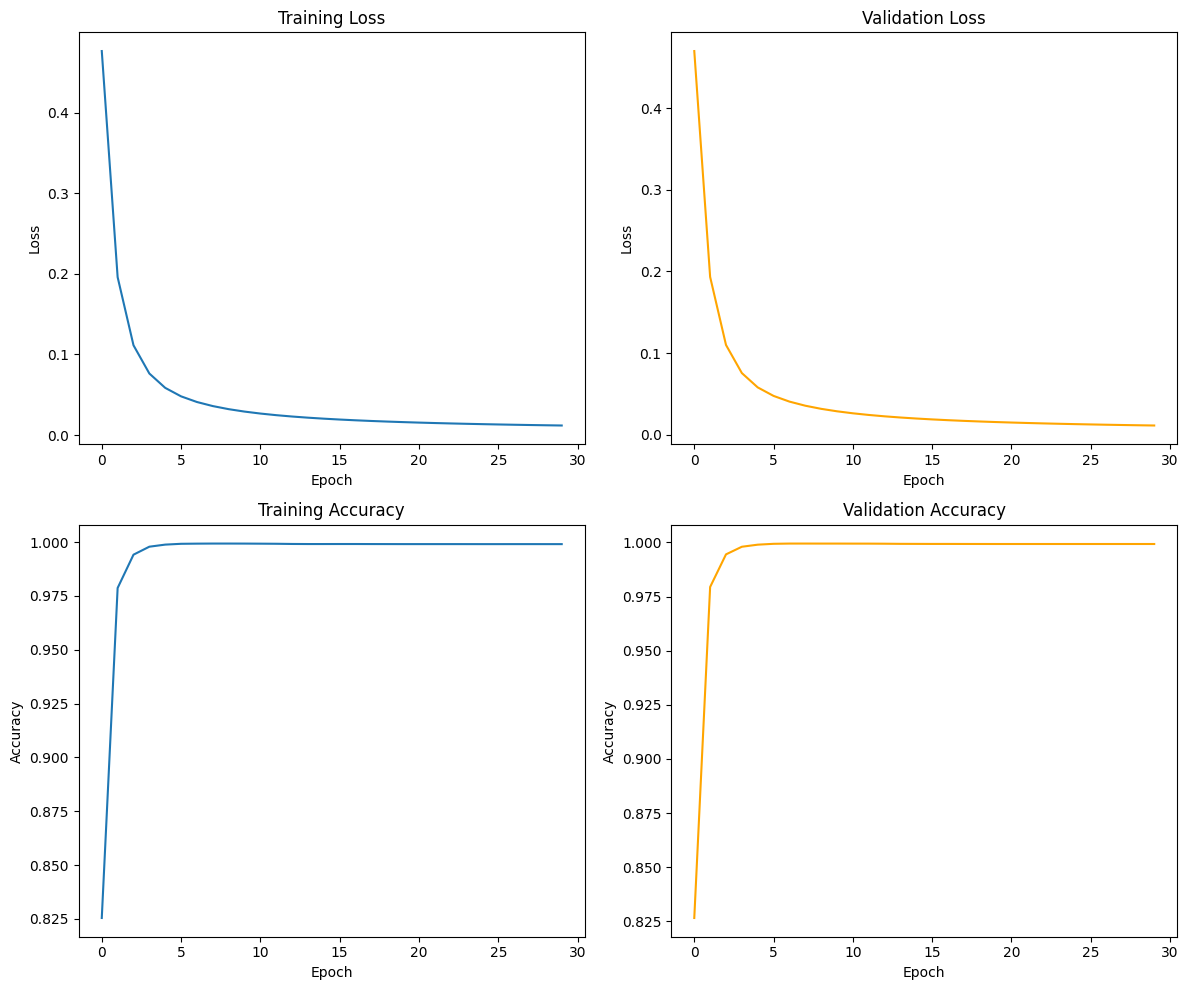

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have already created an instance of Softmax and run the fit method
# softmax_model = Softmax(X_train, X_val, y_train, y_val, lr, theta, epochs, batch_size)
# train_accs, train_losses, val_accs, val_losses = softmax_model.fit()

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(soft.train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(soft.val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(soft.train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(soft.val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.tight_layout()
plt.show()


# ***Twitter Sentiment Analysis***

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
nltk.download("stopwords")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
df2 = pd.read_csv("/content/twitter_sentiment_analysis_3cls_dataset.zip")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [6]:
df2 = df2.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162969 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162969 non-null  object 
 1   category    162969 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.7+ MB


In [7]:
def text_normalize(text):
  # Lowercasing all text
  text = text.lower()
  # Retweet (RT) removal
  text = re.sub(r"^rt[\s]+", "", text)
  # Hyperlink removal
  text = re.sub(r"https?:\/\/.*[\r\n]*", "", text)
  # Punctuation removal
  text = re.sub(r"[^\w\s]", "", text)
  # Remove stopwords
  stop_words = set(stopwords.word("english"))
  words = text.split()
  words = [word for word in words if word not in stop_words]
  text = ' '.join(words)

  # Stremming
  stemmer = SnowballStemmer('english')
  words = text.split()
  words = [stemmer.stem(word) for word in words]
  text = ' '.join(words)

  return text

# Add bias to X
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df2['clean_text']).toarray()
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)

# Encoded y
n_classes = df2['category'].nunique()
n_samples = df2['category'].size
y = df2['category'].to_numpy() + 1
y = y.astype(np.uint8)
y_encoded = np.array([np.zeros(n_classes) for _ in range(n_samples)])
y_encoded[np.arange(n_samples), y] = 1

# Test, val, train test
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y_encoded,
    test_size=val_size,
    random_state=random_state,
    shuffle=is_shuffle,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=random_state,
    shuffle=is_shuffle
)


In [8]:
lr = 0.1
epochs = 200
batch_size = X_train.shape[0]
n_features = X_train.shape[1]

np.random.seed(random_state)
theta = np.random.uniform(size=(n_features, n_classes))
softmax_model = Softmax(X_train, X_val, y_train, y_val, lr, theta, epochs, batch_size)
softmax_model.fit()


EPOCH 1:	Training loss: 1.132	Validation loss: 1.127

EPOCH 2:	Training loss: 1.129	Validation loss: 1.124

EPOCH 3:	Training loss: 1.126	Validation loss: 1.121

EPOCH 4:	Training loss: 1.123	Validation loss: 1.119

EPOCH 5:	Training loss: 1.121	Validation loss: 1.116

EPOCH 6:	Training loss: 1.118	Validation loss: 1.114

EPOCH 7:	Training loss: 1.116	Validation loss: 1.112

EPOCH 8:	Training loss: 1.114	Validation loss: 1.110

EPOCH 9:	Training loss: 1.112	Validation loss: 1.108

EPOCH 10:	Training loss: 1.110	Validation loss: 1.106

EPOCH 11:	Training loss: 1.108	Validation loss: 1.104

EPOCH 12:	Training loss: 1.106	Validation loss: 1.103

EPOCH 13:	Training loss: 1.105	Validation loss: 1.101

EPOCH 14:	Training loss: 1.103	Validation loss: 1.100

EPOCH 15:	Training loss: 1.102	Validation loss: 1.098

EPOCH 16:	Training loss: 1.101	Validation loss: 1.097

EPOCH 17:	Training loss: 1.099	Validation loss: 1.096

EPOCH 18:	Training loss: 1.098	Validation loss: 1.095

EPOCH 19:	Training

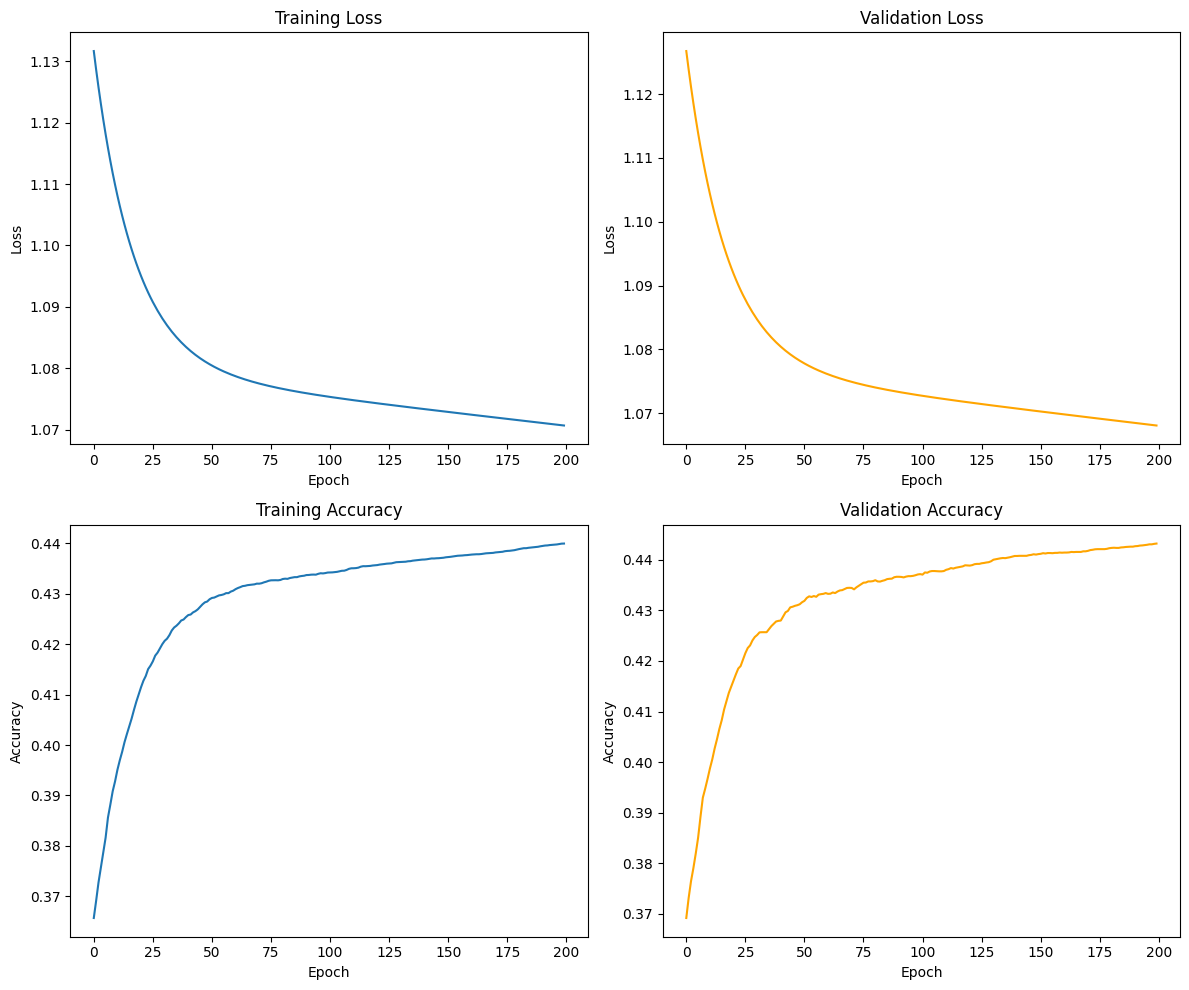

In [9]:
import matplotlib.pyplot as plt

# Assuming you have already created an instance of Softmax and run the fit method
# softmax_model = Softmax(X_train, X_val, y_train, y_val, lr, theta, epochs, batch_size)
# train_accs, train_losses, val_accs, val_losses = softmax_model.fit()

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(softmax_model.train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(softmax_model.val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(softmax_model.train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(softmax_model.val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.tight_layout()
plt.show()


In [15]:
y_hat = np.array([0.4, 0.15, 0.05, 0.4])
y = np.array([1, 0, 0, 0])
def loss(y_hat, y):
    n = y.size
    return -np.sum(y * np.log(y_hat))

loss(y_hat, y)

0.916290731874155

In [16]:
y_hat = np.array([0, 1, 3, 2, 0, 2, 1, 2])
y = np.array([0, 0, 3, 2, 1, 2, 2, 1])

def accuracy(y_hat, y):
    return (y_hat == y).mean()

accuracy(y_hat, y)

0.5

In [ ]:
z = np.array([-1, -2, 3, 2])
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=0, keepdims=True)[:, None]

softmax(z)

array([[0.01314897, 0.00483724, 0.71790961, 0.26410418]])